In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
H = -1.5

In [3]:
# Canonical coords (found from the usual definition)
def phys_to_canonical(x, y, z, dx, dy, dz):
    px = dx + y
    py = dy + x + 1
    pz = dz
    return [x, y, z, px, py, pz]

# Hamiltonian
def H0(state: list) -> float:
    """unperturbed Hamiltonian"""
    x, y, z, px, py, pz = state
    
    return (0.5*(px - y)**2 + 0.5*(py - x - 1)**2 + 0.5*pz**2
          - 1.5 - 1.5*x**2 - 0.5*z**2)

def H1(x: float, y: float, z: float) -> float:
    """perturbing Hamiltonian"""
    return (x**3 - 1.5*x*y**2 - 1.5*x*z**2
            - x**4 + 3*x**2*y**2 + 3*x**2*z**2
            - 0.375*y**4 - 0.75*y**2*z**2 - 0.375*z**4)

def H_canonical(state):
    """Hamiltonian"""
    x, y, z, px, py, pz = state
    return H0(state) + H1(x, y, z)

Hamilton's canonical equations

$$
\begin{cases}
\dot{x} = \dfrac{\partial \mathcal{H}}{\partial p_x} = p_x - y, \\[1em]
\dot{y} = \dfrac{\partial \mathcal{H}}{\partial p_y} = p_y - x - 1, \\[1em]
\dot{z} = \dfrac{\partial \mathcal{H}}{\partial p_z} = p_z, \\[1em]
\dot{p}_x = -\dfrac{\partial \mathcal{H}}{\partial x} = -\left( \dfrac{\partial \mathcal{H}^{(0)}}{\partial x} + \dfrac{\partial \mathcal{H}^{(1)}}{\partial x} \right), \\[1em]
\dot{p}_y = -\dfrac{\partial \mathcal{H}}{\partial y} = -\left( \dfrac{\partial \mathcal{H}^{(0)}}{\partial y} + \dfrac{\partial \mathcal{H}^{(1)}}{\partial y} \right), \\[1em]
\dot{p}_z = -\dfrac{\partial \mathcal{H}}{\partial z} = -\left( \dfrac{\partial \mathcal{H}^{(0)}}{\partial z} + \dfrac{\partial \mathcal{H}^{(1)}}{\partial z} \right).
\end{cases}
$$

In [4]:
def dH1dx(x: float, y: float, z: float) -> float:
    """ dH1 / dx """
    return 3*x**2 - 1.5*y**2 - 1.5*z**2 - 4*x**3 + 6*x*y**2 + 6*x*z**2

def dH1dy(x: float, y: float, z: float) -> float:
    """ dH1 / dy """
    return -3*x*y + 6*x**2*y - 1.5*y**3 - 1.5*y*z**2

def dH1dz(x: float, y: float, z: float) -> float:
    """ dH1 / dz """
    return -3*x*z + 6*x**2*z - 1.5*y**2*z - 1.5*z**3

In [5]:
def rhs_canonical(t, state):
    """Right-hand side of the differential equation"""
    x, y, z, px, py, pz = state

    dx = px - y
    dy = py - x - 1
    dz = pz

    dpx = (py - x - 1) + 3*x - dH1dx(x, y, z)
    dpy = (px - y) - dH1dy(x, y, z)
    dpz = z - dH1dz(x, y, z)

    return [dx, dy, dz, dpx, dpy, dpz]

# Событие: пересечение y=0
def event_y0(t, state):
    return state[1]   # y
event_y0.direction = 0
event_y0.terminal = False

Hamiltonian as the sum of a linear part and a perturbed part:

$$
\mathcal{H} = \mathcal{H}^{(0)} + \mathcal{H}^{(1)} = \frac{1}{2}(\dot{x}^2 + \dot{y}^2 + \dot{z}^2) - \frac{3}{2} - \frac{3}{2}x^2 - \frac{1}{2}z^2 + \mathcal{H}^{(1)}
$$

So the square of the initial velocity (y) is equal to:

$$
\dot{y}_0^2 = 2\left(\mathcal{H} + \frac{3}{2} + \frac{3}{2}x_0^2 + \frac{1}{2}z_0^2 - \mathcal{H}^{(1)}(x_0, 0, z_0)\right) - \dot{x}_0^2 - \dot{z}_0^2.
$$

In [6]:
def generate_initial_conditions() -> np.ndarray:
    """Initial conditions generating"""

    initial_conditions = []
    for x0 in np.linspace(-0.10, 0, 50):            # selection of initial x
        for vx0 in np.linspace(-0.1, 0.1, 10):      # selection of initial vx
            for z0 in [0.0, 0.05, 0.1]:             # selection of initial z
                for vz0 in [-0.1, 0.0, 0.1]:        # selection of initial vz

                    vy0_sq = 2*(H + 1.5 + 1.5*x0**2 + 0.5*z0**2 - H1(x0, 0.0, z0)) - vx0**2 - vz0**2
                    if vy0_sq < 0:
                        continue

                    vy0 = np.sqrt(vy0_sq)
                    for sign in [1]:
                        state_can = phys_to_canonical(x0, 0.0, z0, vx0, sign*vy0, vz0)
                        if abs(H_canonical(state_can) - H) < 1e-8:
                            initial_conditions.append(state_can)
                    
    return initial_conditions

initial_conditions = generate_initial_conditions()

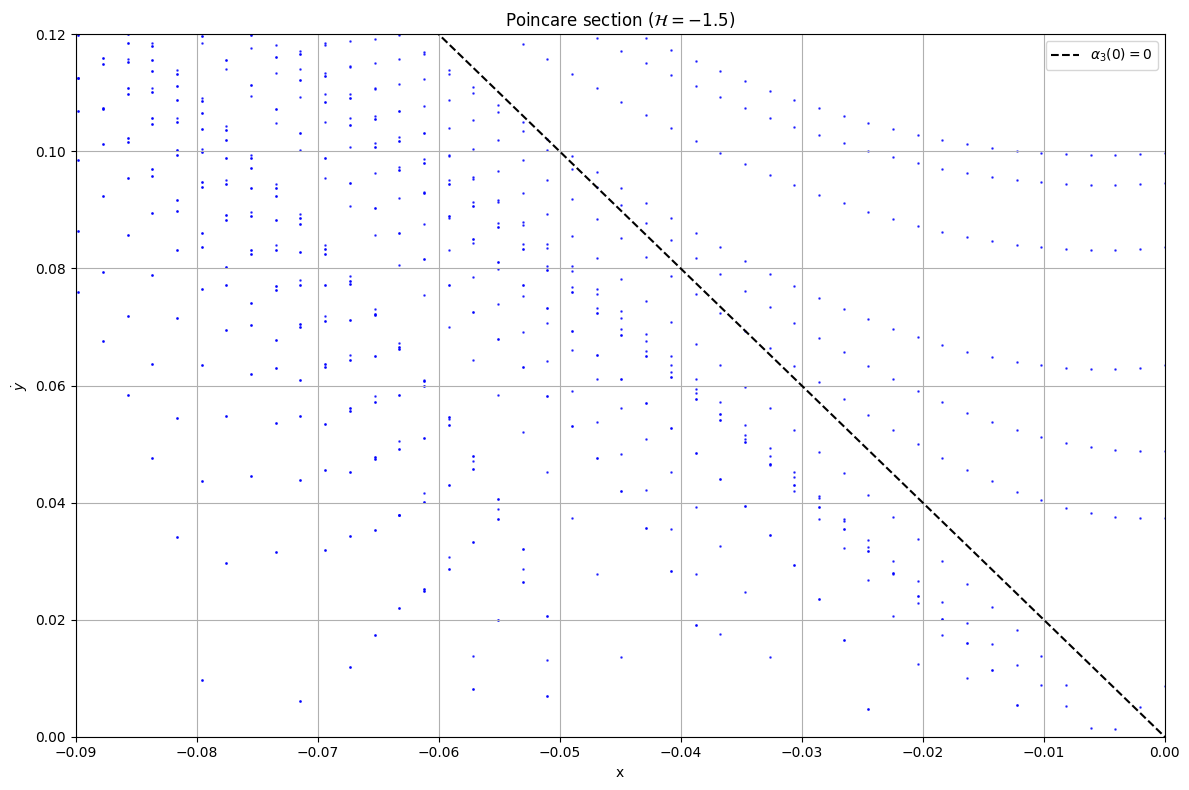

In [12]:
def plot_poincare_section(initial_conditions: np.ndarray) -> np.ndarray:
    """
    Poincare section {(x, dy) : dx > 0 and y = 0}
    :param initial_conditions: array of initial conditions
    :return: array of DE solutions
    """

    plt.figure(figsize=(12,8))
    
    all_points = []  # [x, vy, time]
    
    for state0 in initial_conditions:
        t_span = (0, 200*np.pi)
        sol = solve_ivp(rhs_canonical, t_span, state0, method='RK45',
                        events=event_y0, rtol=1e-9, atol=1e-9, max_step=0.1)
        
        if sol.t_events[0] is not None:
            x_events = sol.y_events[0][:, 0]
            y_events = sol.y_events[0][:, 1]
            px_events = sol.y_events[0][:, 3]
            py_events = sol.y_events[0][:, 4]
            vx_events = px_events - y_events
            vy_events = py_events - x_events - 1
            
            for j, t in enumerate(sol.t_events[0]):
                if vx_events[j] > 0:
                    all_points.append([x_events[j], vy_events[j], t])
                    
            mask = vx_events > 0
            plt.scatter(x_events[mask], vy_events[mask], s=0.7, alpha=0.7, color='blue')
    
    # alpha_3(0) = 0
    x_line = np.linspace(-0.1, 0.01, 100)
    plt.plot(x_line, -2*x_line, 'k--', label=r'$\alpha_3(0)=0$')

    plt.xlabel('x')
    plt.ylabel(r'$\dot{y}$')
    plt.title(r'$\text{Poincare section } (\mathcal{H} = -1.5)$')
    plt.grid(True)
    plt.legend()
    plt.xlim(-0.09, 0)
    plt.ylim(0, 0.12)

    plt.tight_layout()
    plt.show()
    
    return np.array(all_points)


points = plot_poincare_section(initial_conditions)

In [10]:
# TODO

def find_periodic_candidates(points: np.ndarray, tol: float = 1e-6, min_count: int = 3) -> list:
    """Find candidates for periodic solutions - points with same (x, vy) at different times"""
    
    point_dict = {}
    for i in range(len(points)):
        x, vy, t = points[i]

        key = (round(x / tol) * tol, round(vy / tol) * tol)
        
        if key not in point_dict:
            point_dict[key] = set()
        point_dict[key].add(t)
    
    candidates = []
    for (x, vy), times_set in point_dict.items():
        times = sorted(times_set)
        if len(times) >= min_count:
            candidates.append((x, vy, times))
    
    return candidates